In [44]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Deep Evidential Regression

This notebook is based on [_Deep Evidential Regression_ by Amini et al.](https://arxiv.org/pdf/1910.02600) and [Evidential Deep Learning in PyTorch](https://github.com/teddykoker/evidential-learning-pytorch).

Let's assume we have a dataset, $\mathcal{D}$, with $N$ observations, $\mathcal{D} = \{ \mathbf{x}_i, y_i \}_{i=1}^N $.

We assume that 
$$
y_i = f_w(\mathbf{x}_i) + \epsilon_i \\
\epsilon_i \stackrel{\text{iid}}{\sim} \mathcal{N}(0, \sigma^2)
$$


### Toy Dataset

Let's create a toy dataset with 
$$
x_i \in [-4, 4] \\
y_i = x_i^3 + \epsilon_i \\
\epsilon_i \sim \mathcal{N}(0, 3^2)
$$



In [45]:
N = 1000
TRAIN_BOUNDS = (-4, 4)
TEST_BOUNDS = (-7, 7)

x_train = np.linspace(TRAIN_BOUNDS[0], TRAIN_BOUNDS[1], N).reshape(-1, 1)
y_train = x_train**3 + np.random.normal(0, 3, size=(N, 1))

x_test = np.linspace(TEST_BOUNDS[0], TEST_BOUNDS[1], N).reshape(-1, 1)
y_test = x_test**3

In [46]:
# Prepare data for PyTorch
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(x_train), torch.FloatTensor(y_train)
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)


def get_infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


train_loader_inf = iter(get_infinite_loader(train_loader))

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(x_test), torch.FloatTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

**Deep Evidential Regression** aims to _directly learn both the aleatoric uncertainty present in the data as well as the model's underlying epistemic uncertainty_.

For **Deep Evidential Regression**, we assume

$$
y_i \sim \mathcal{N}(\mu_i, \sigma_i^2) \\
\mu_i \sim \mathcal{N}(\gamma, \sigma_i^2 * v^{-1}) \\
\sigma_i^2 \sim \Gamma^{-1}(\alpha, \beta)
$$

meaning we treat $\mu$ and $\sigma^2$ as unknown and place prior distributions on them.
The goal is to estimate the posterior distribution $p(\mu, \sigma^2 | \mathcal{D})$. Due to conjuacy, this distribution will be a **Normal-Inverse-Gamma** distribution.

We can compute the prediction, aleatoric and epistemic uncertainty from this posterior distribution:
1. Prediction
$$
\mathbb{E}[\mu] = \gamma
$$

2. Aleatoric uncertainty
$$
\mathbb{E}[\sigma^2] = \frac{\beta}{\alpha - 1}
$$

3. Epistemic uncertainty
$$
\mathbb{V}[\mu] = \frac{\beta}{v(\alpha - 1)}
$$

The question remains how to find the parameters $\mathbf{m} = \gamma, v, \alpha, \beta$.
Simply put, we use a Neural Network to infer $m$ given an input $\mathbf{x}$.

### Neural Network Architecture

The model is a simple fully-connected network that outputs four parameters for each input:
- **$\gamma$**: The predicted mean
- **$v$**: The precision of the prior over $\mu$
- **$\alpha$**: The shape parameter of the inverse gamma distribution
- **$\beta$**: The scale parameter of the inverse gamma distribution

These parameters fully define the Normal-Inverse-Gamma posterior distribution. We apply softplus activation to ensure $v$, $\alpha$, and $\beta$ are positive, and add 1 to $\alpha$ to ensure $\alpha > 1$ (required for the uncertainty computations).

In [47]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, layers=4):
        super(RegressionMLP, self).__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layers = nn.ModuleList(
            [nn.Linear(hidden_dim, hidden_dim) for _ in range(layers - 1)]
        )
        self.output_layer = nn.Linear(hidden_dim, 4)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = F.relu(layer(x))
        x = self.output_layer(x)

        gamma, logv, logalpha, logbeta = torch.split(x, 1, dim=-1)
        v = F.softplus(logv)
        alpha = F.softplus(logalpha) + 1
        beta = F.softplus(logbeta)

        # clamp v, alpha, beta to prevent numerical issues
        v = torch.clamp(v, min=1e-6)
        alpha = torch.clamp(alpha, min=1 + 1e-6)
        beta = torch.clamp(beta, min=1e-6)

        return torch.cat([gamma, v, alpha, beta], dim=-1)

In [48]:
def compute_prediction(gamma, _v, _alpha, _beta):
    return gamma


def compute_aleatoric_uncertainty(_gamma, _v, alpha, beta):
    return np.sqrt(beta / (alpha - 1))


def compute_epistemic_uncertainty(_gamma, v, alpha, beta):
    return np.sqrt(beta / (v * (alpha - 1)))

### Loss Functions

The evidential loss consists of two components:

1. **NLL Loss (nig_nll)**: The negative log-likelihood of the Normal-Inverse-Gamma distribution, which encourages the model to place probability mass on the true target values.

2. **Regularization Loss (nig_reg)**: An additional term that penalizes the model for making confident predictions far from the true targets. This helps prevent overconfident predictions in out-of-distribution regions.

The total loss is: `loss = nll_loss + λ * reg_loss`, where λ controls the strength of regularization.

In [49]:
def nig_nll(gamma, v, alpha, beta, y):
    omega = 2 * beta * (1 + v)
    t1 = 0.5 * (torch.pi / v).log()
    t2 = alpha * omega.log()
    t3 = (alpha + 0.5) * (v * (y - gamma) ** 2 + omega).log()
    t4 = alpha.lgamma()
    t5 = (alpha + 0.5).lgamma()
    nll = t1 - t2 + t3 + t4 - t5
    return nll.mean()


def nig_reg(gamma, v, alpha, _beta, y):
    reg = (y - gamma).abs() * (2 * v + alpha)
    return reg.mean()


def evidential_loss(gamma, v, alpha, beta, y, reg_lambda):
    nll_loss = nig_nll(gamma, v, alpha, beta, y)
    reg_loss = nig_reg(gamma, v, alpha, beta, y)
    return nll_loss + reg_lambda * reg_loss, (nll_loss, reg_loss)

### Training the Model on Toy Dataset

We'll train the model for 5,000 iterations using Adam optimizer.

In [50]:
model = RegressionMLP()
optimizer = optim.Adam(model.parameters(), lr=5e-4)
reg_lambda = 1e-3
num_iterations = 5_000

loss_history_list = []

for iteration in tqdm(range(num_iterations)):
    model.train()
    batch_x, batch_y = next(train_loader_inf)
    optimizer.zero_grad()
    outputs = model(batch_x)
    gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]
    loss, (nll_loss, reg_loss) = evidential_loss(
        gamma, v, alpha, beta, batch_y[:, 0], reg_lambda
    )
    loss.backward()
    optimizer.step()

    # Logging
    loss_history_list.append((loss.item(), nll_loss.item(), reg_loss.item()))

# convert history list to running average for smoother plots
loss_history = np.array(loss_history_list)
window_size = 100
loss_history = np.array(
    [
        np.convolve(
            loss_history[:, i], np.ones(window_size) / window_size, mode="valid"
        )
        for i in range(loss_history.shape[1])
    ]
).T

100%|██████████| 5000/5000 [00:07<00:00, 681.84it/s]


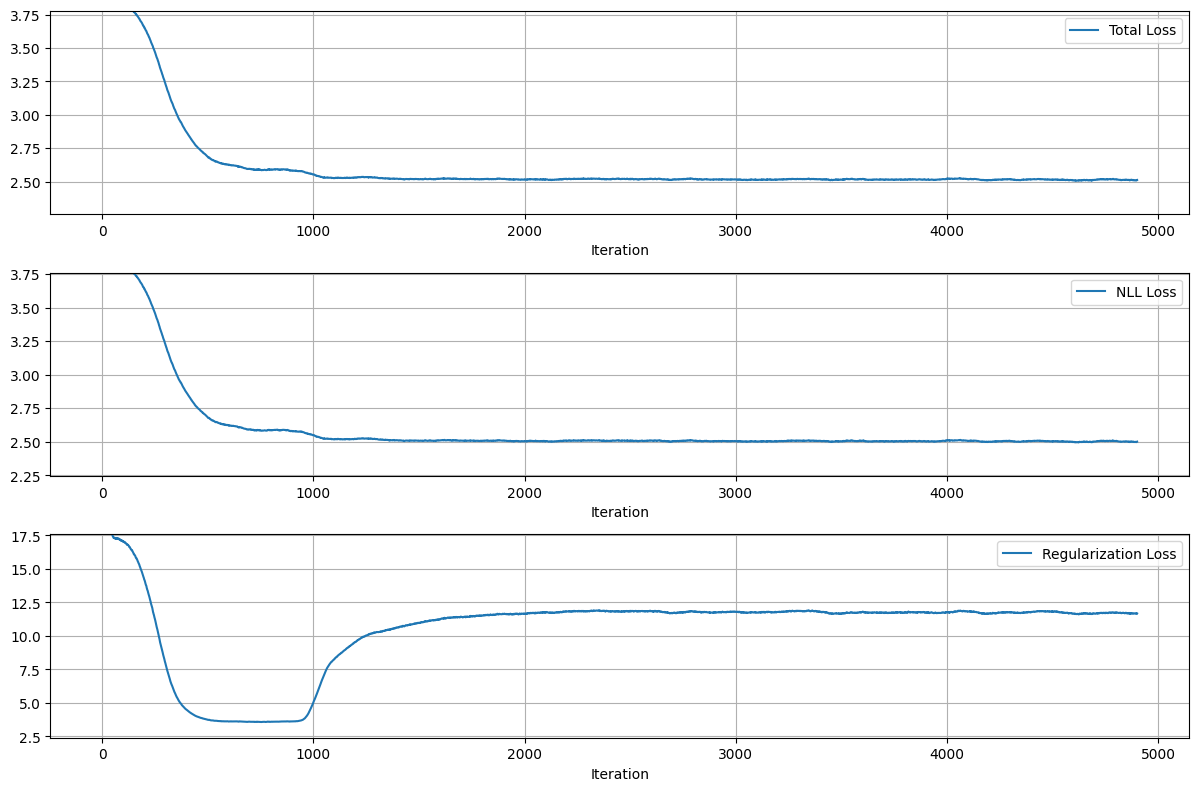

In [51]:
# visualize training losses
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs[0].plot(loss_history[:, 0], label="Total Loss")
axs[1].plot(loss_history[:, 1], label="NLL Loss")
axs[2].plot(loss_history[:, 2], label="Regularization Loss")
for i, ax in enumerate(axs):
    ax.grid()
    ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_ylim(
        np.percentile(loss_history[:, i], 0)
        - 0.1 * np.percentile(loss_history[:, i], 50),
        np.percentile(loss_history[:, i], 50) * 1.5,
    )

fig.tight_layout()

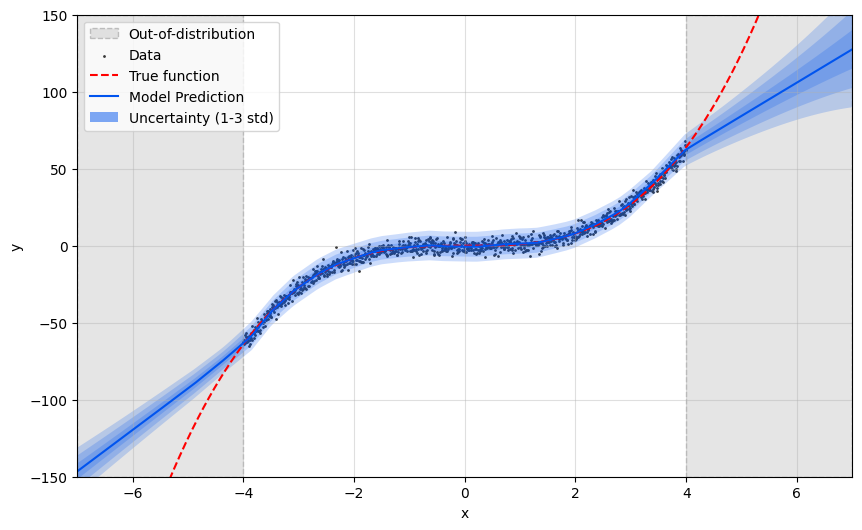

In [52]:
outputs = model(torch.FloatTensor(x_test)).detach().cpu().numpy()
gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]

y_pred = compute_prediction(gamma, v, alpha, beta)
uncertainty_epistemic = compute_epistemic_uncertainty(gamma, v, alpha, beta)
uncertainty_aleatoric = compute_aleatoric_uncertainty(gamma, v, alpha, beta)
uncertainty_total = np.sqrt(uncertainty_aleatoric**2 + uncertainty_epistemic**2)


fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(alpha=0.4)
ax.axvspan(
    TEST_BOUNDS[0],
    TRAIN_BOUNDS[0],
    edgecolor="black",
    linestyle="--",
    facecolor="gray",
    alpha=0.2,
    label="Out-of-distribution",
)
ax.axvspan(
    TRAIN_BOUNDS[1],
    TEST_BOUNDS[1],
    edgecolor="black",
    linestyle="--",
    facecolor="gray",
    alpha=0.2,
)
ax.scatter(x_train, y_train, s=1, c="#393939", label="Data")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.plot(x_test, y_test, c="red", linestyle="--", label="True function")

ax.plot(x_test, y_pred, c="#0054ef", label="Model Prediction")
for k in np.linspace(1, 3, 3):
    ax.fill_between(
        x_test[:, 0],
        y_pred - k * uncertainty_total,
        y_pred + k * uncertainty_total,
        color="#0054ef",
        edgecolor=None,
        alpha=0.2,
    )
ax.set_ylim(-150, 150)
ax.set_xlim(TEST_BOUNDS[0], TEST_BOUNDS[1])

# add legend entry for uncertainty
unc_patch = plt.Rectangle(
    (0, 0), 1, 1, fc="#0054ef", alpha=0.5, label="Uncertainty (1-3 std)"
)
ax.add_artist(unc_patch)

ax.legend(loc="upper left")

### Uncertainty Decomposition

The plot below shows how the two types of uncertainty behave differently:

- **Aleatoric uncertainty** (green) remains relatively constant across the input space, representing the inherent noise in the data ($\sigma^2 = 3^2$).
- **Epistemic uncertainty** (orange) increases in the out-of-distribution regions (|x| > 4) where the model hasn't seen training data, reflecting the model's lack of knowledge about these regions.

(0.0, 10.0)

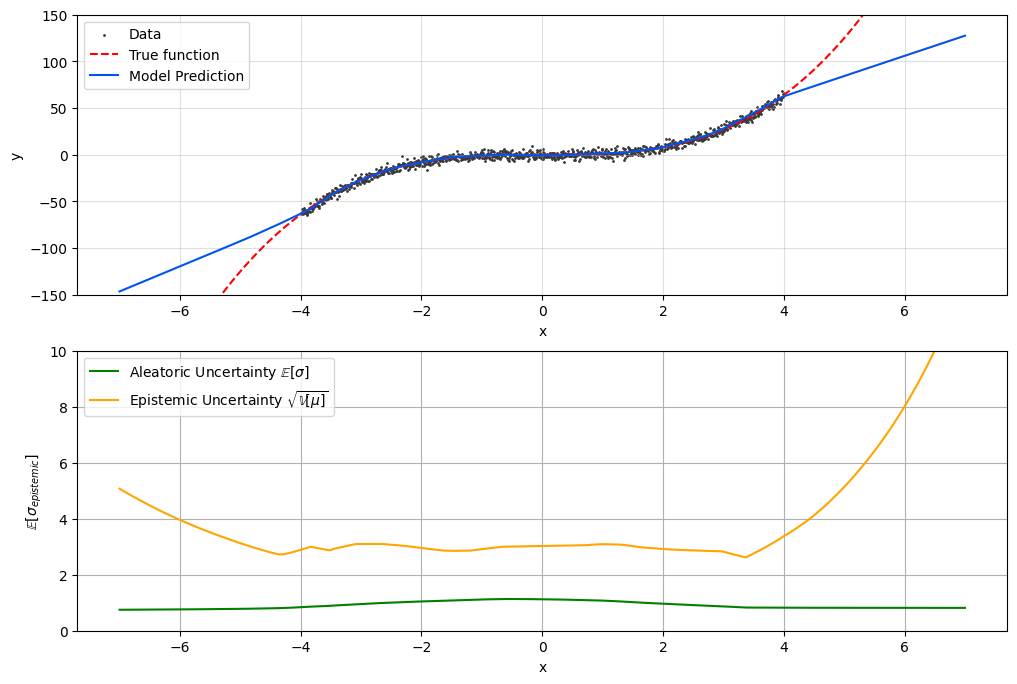

In [53]:
fig, axs = plt.subplots(nrows=2, figsize=(12, 8))

axs[0].grid(alpha=0.4)
axs[0].scatter(x_train, y_train, s=1, c="#393939", label="Data")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].plot(x_test[:, 0], y_test, c="red", linestyle="--", label="True function")
axs[0].set_ylim(-150, 150)
axs[0].plot(x_test[:, 0], y_pred, c="#0054ef", label="Model Prediction")
axs[0].legend()


axs[1].grid()
axs[1].plot(
    x_test[:, 0],
    uncertainty_aleatoric,
    label=r"Aleatoric Uncertainty $\mathbb{E}[\sigma]$",
    c="green",
)
axs[1].set_xlabel("x")
axs[1].set_ylabel(r"$\mathbb{E}[\sigma]$")

axs[1].plot(
    x_test[:, 0],
    uncertainty_epistemic,
    label=r"Epistemic Uncertainty $\sqrt{\mathbb{V}[\mu]}$",
    c="orange",
)
axs[1].set_xlabel("x")
axs[1].set_ylabel(r"$\mathbb{E}[\sigma_{epistemic}]$")
axs[1].legend()
axs[1].set_ylim(0, 10)

## Year Prediction MSD

The Year Prediction MSD dataset contains audio features extracted from songs, with the goal of predicting the release year of each song. This is a real-world regression problem with:
- **Features**: 90 timbre-based audio features
- **Target**: Release year of the song
- **Size**: Over 500,000 samples spanning decades of music

This dataset is ideal for testing evidential regression because we can examine how uncertainty varies across different time periods, especially for years that are underrepresented in the training data.

In [ ]:
data_path = Path("data") / "yearpredictionmsd.csv"
if not data_path.exists():
    data_path.parent.mkdir(exist_ok=True)
    url = "https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip"
    df = pd.read_csv(url, header=None)
    df.to_csv(data_path, index=False)
else:
    df = pd.read_csv(data_path)

# The first column is the year (Target), the rest are audio features
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

(515345, 90)

### Data Preprocessing and Split

We split the data by training only on songs released before 1990, then test on the full dataset. This creates a distribution shift where years ≥ 1990 are out-of-distribution during training.

We apply standard scaling to the features (zero mean, unit variance) using only the training data statistics to prevent data leakage. The target variable statistics are also computed for normalization during training.

In [13]:
# Official Split
# X_train, X_test = X[:463715], X[463715:]
# y_train, y_test = y[:463715], y[463715:]

X_train, X_test = X[y < 1990], X
y_train, y_test = y[y < 1990], y

# SCALE EVERYTHING
scaler_x = StandardScaler().fit(X_train)
X_train, X_test = scaler_x.transform(X_train), scaler_x.transform(X_test)

y_mean, y_std = y_train.mean(), y_train.std()

In [14]:
# Prepare data for PyTorch
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_train.copy()), torch.FloatTensor(y_train.copy())
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
train_loader_inf = iter(get_infinite_loader(train_loader))

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test.copy()), torch.FloatTensor(y_test.copy())
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

### Training on Real Dataset

For this more complex dataset, we use a larger network (128 hidden units, 5 layers) and train for 10,000 iterations. The regularization coefficient is increased to 1e-3 to help the model handle the higher-dimensional input space.

We normalize the target values during training to improve stability, using the mean and standard deviation from the training set.

In [ ]:
model = RegressionMLP(input_dim=X_train.shape[1], hidden_dim=128, layers=5)
optimizer = optim.Adam(model.parameters(), lr=3e-3)
reg_lambda = 1e-3
reg_start = 2_000
reg_full = 5_000
num_iterations = 10_000

loss_history_list = []
mean_outputs_list = []

for iteration in tqdm(range(num_iterations)):
    model.train()
    batch_x, batch_y = next(train_loader_inf)
    optimizer.zero_grad()
    outputs = model(batch_x)
    gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]
    batch_y_norm = (batch_y - y_mean) / y_std

    loss, (nll_loss, reg_loss) = evidential_loss(
        gamma, v, alpha, beta, batch_y_norm, reg_lambda=reg_lambda
    )
    loss.backward()
    optimizer.step()

    # Logging
    loss_history_list.append((loss.item(), nll_loss.item(), reg_loss.item()))
    mean_outputs_list.append(outputs.mean(dim=0).detach().cpu().numpy())

# turn mean outputs into running average for smoother plots
mean_outputs = np.array(mean_outputs_list)
window_size = 100
mean_outputs_smooth = np.array(
    [
        np.convolve(
            mean_outputs[:, i], np.ones(window_size) / window_size, mode="valid"
        )
        for i in range(mean_outputs.shape[1])
    ]
).T
loss_history = np.array(loss_history_list)
loss_history_smooth = np.array(
    [
        np.convolve(
            loss_history[:, i], np.ones(window_size) / window_size, mode="valid"
        )
        for i in range(loss_history.shape[1])
    ]
).T
del loss_history_list
del mean_outputs_list

100%|██████████| 10000/10000 [00:23<00:00, 418.80it/s]


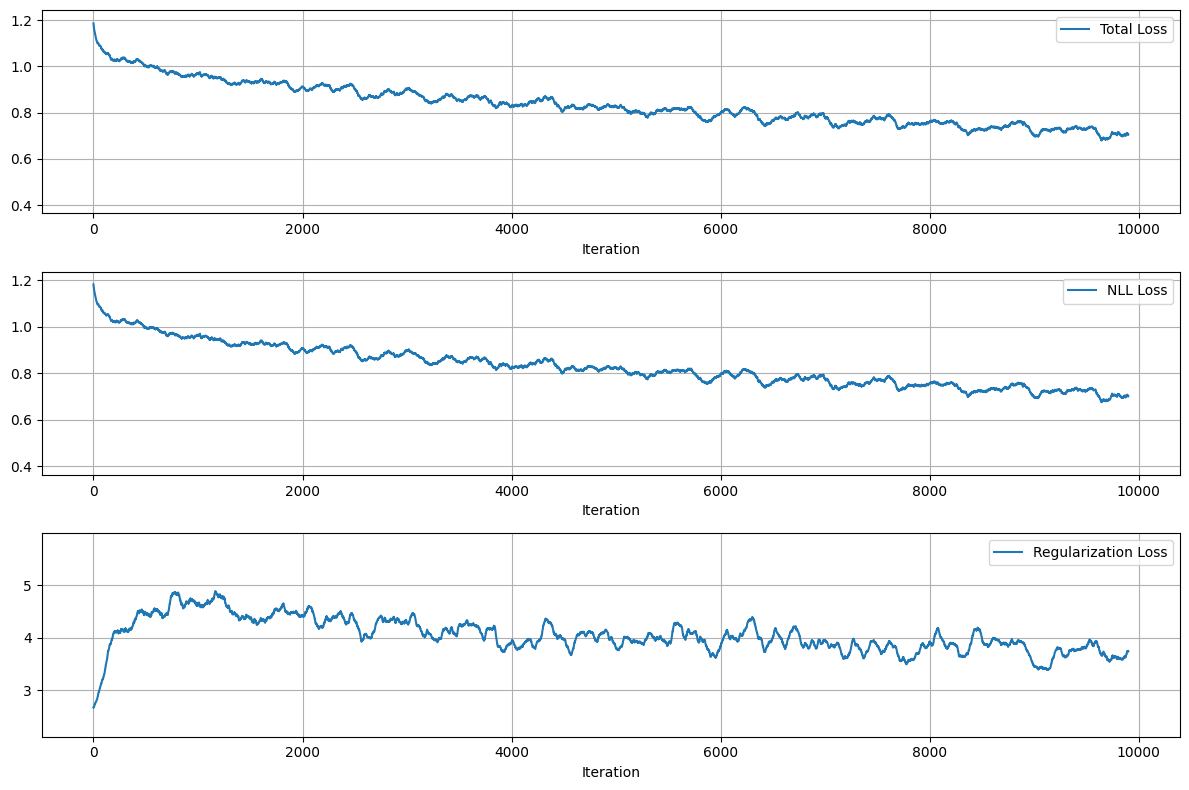

In [16]:
# visualize training losses
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
axs[0].plot(loss_history_smooth[:, 0], label="Total Loss")
axs[1].plot(loss_history_smooth[:, 1], label="NLL Loss")
axs[2].plot(loss_history_smooth[:, 2], label="Regularization Loss")
for i, ax in enumerate(axs):
    ax.grid()
    ax.legend()
    ax.set_xlabel("Iteration")
    ax.set_ylim(
        np.nanpercentile(loss_history[:, i], 0),
        np.nanpercentile(loss_history[:, i], 50) * 1.5,
    )

fig.tight_layout()

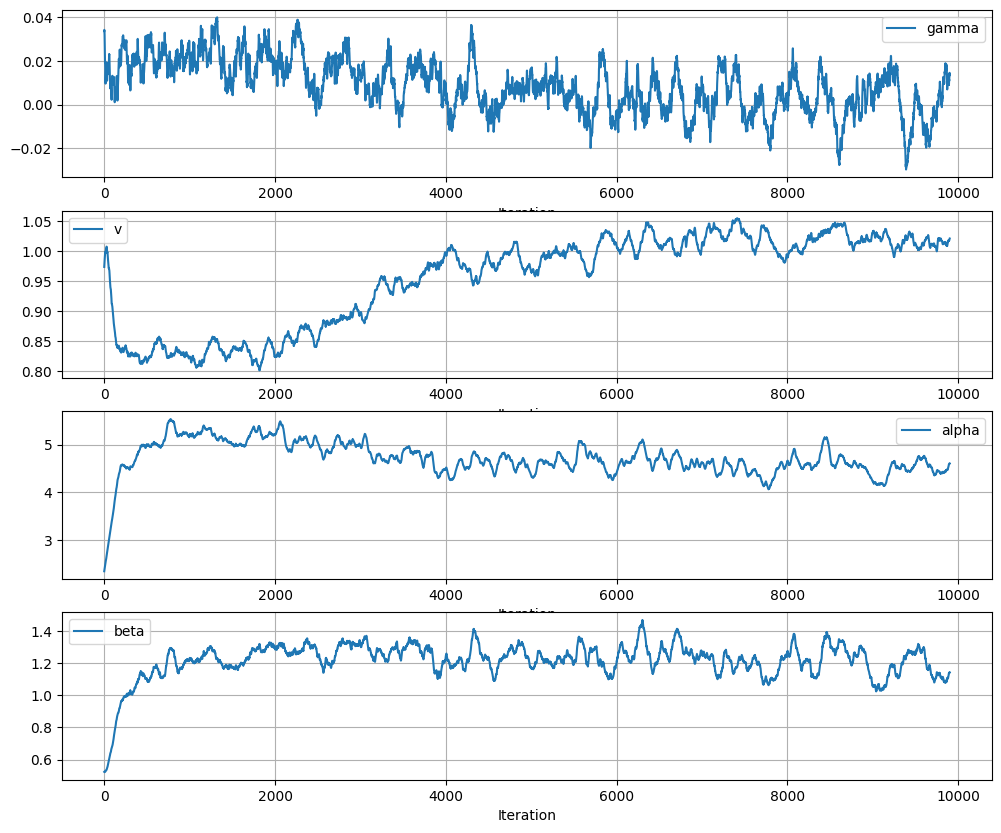

In [17]:
# visualize output evolution
fig, axs = plt.subplots(4, 1, figsize=(12, 10))
output_names = ["gamma", "v", "alpha", "beta"]
for i, ax in enumerate(axs):
    ax.plot(mean_outputs_smooth[:, i], label=output_names[i])
    ax.grid()
    ax.legend()
    ax.set_xlabel("Iteration")

In [18]:
def unnormalize_output(gamma, v, alpha, beta, y_mean, y_std):
    gamma_unnorm = gamma * y_std + y_mean
    v_unnorm = v * (y_std**2)
    alpha_unnorm = alpha
    beta_unnorm = beta * (y_std**2)
    return gamma_unnorm, v_unnorm, alpha_unnorm, beta_unnorm

In [19]:
# rmse on test set
model.eval()
outputs = model(torch.FloatTensor(X_test)).detach().cpu().numpy()
gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]
gamma, v, alpha, beta = unnormalize_output(gamma, v, alpha, beta, y_mean, y_std)
y_pred = compute_prediction(gamma, v, alpha, beta)
rmse = np.sqrt(np.mean((y_pred - y_test) ** 2))
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 21.7972


### Uncertainty Analysis by Year

One of the key advantages of evidential deep learning is the ability to decompose uncertainty into two types:

- **Epistemic Uncertainty**: Model uncertainty due to limited training data. Should be higher for years that are underrepresented or absent in the training set (≥ 1990).
- **Aleatoric Uncertainty**: Data uncertainty inherent in the problem. Represents the natural variability in predicting release years from audio features.

The following visualizations show how these uncertainties vary across different years, which can reveal which time periods the model is most confident about.

Text(0, 0.5, 'Epistemic Uncertainty')

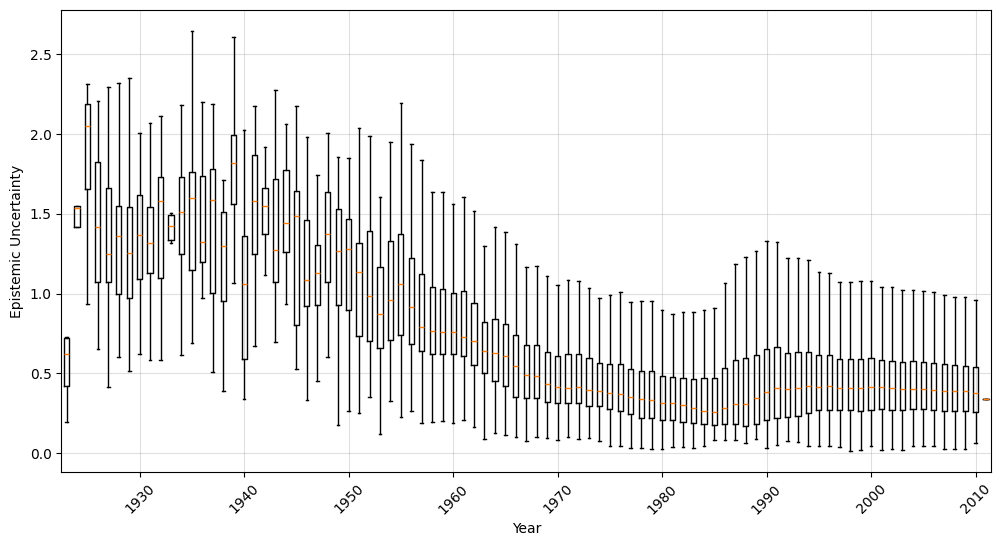

In [20]:
uncertainty_epistemic = compute_epistemic_uncertainty(gamma, v, alpha, beta)

# compute average uncertainty per year
years = np.unique(y_test)

# visualize uncertainty per year (box plots)
fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(alpha=0.4)
ax.boxplot(
    [uncertainty_epistemic[y_test.flatten() == year] for year in years],
    showfliers=False,
)

# keep only decade tick labels
decade_mask = years % 10 == 0
tick_positions = np.arange(1, len(years) + 1)[decade_mask]
tick_labels = years[decade_mask]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Epistemic Uncertainty")

Text(0, 0.5, 'Aleatoric Uncertainty')

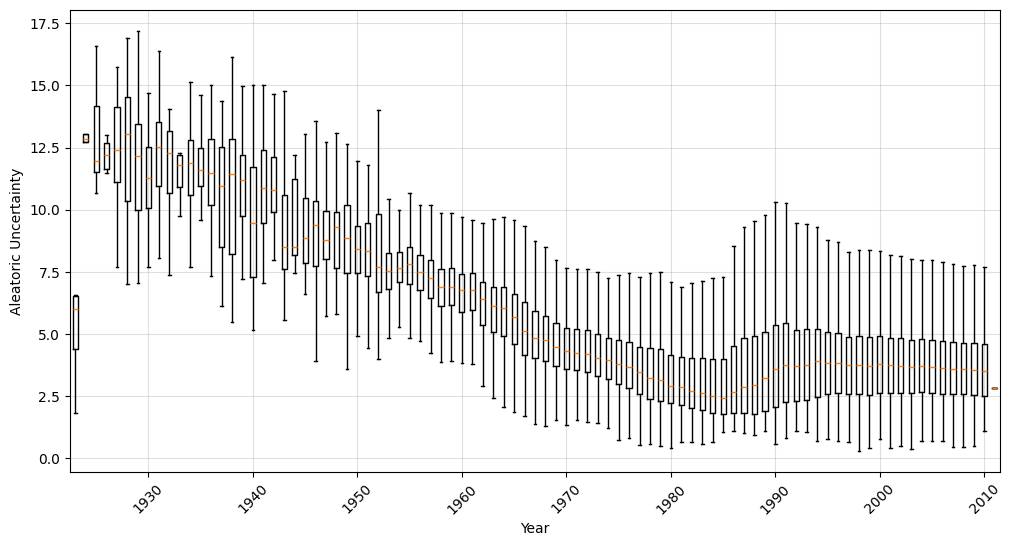

In [21]:
# visualize aleatoric uncertainty per year (box plots)
uncertainty_aleatoric = compute_aleatoric_uncertainty(gamma, v, alpha, beta)
fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(alpha=0.4)
ax.boxplot(
    [uncertainty_aleatoric[y_test.flatten() == year] for year in years],
    showfliers=False,
)

# keep only decade tick labels
decade_mask = years % 10 == 0
tick_positions = np.arange(1, len(years) + 1)[decade_mask]
tick_labels = years[decade_mask]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_xlabel("Year")
ax.set_ylabel("Aleatoric Uncertainty")

Text(0, 0.5, 'RMSE')

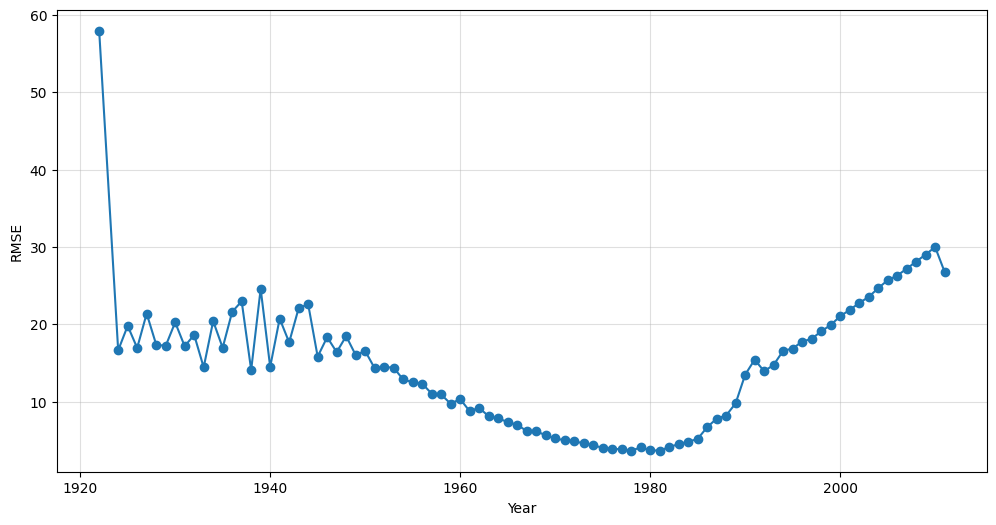

In [22]:
# visualize rmse per year
rmse_per_year = []
for year in years:
    mask = y_test.flatten() == year
    rmse_year = np.sqrt(np.mean((y_pred[mask] - y_test[mask]) ** 2))
    rmse_per_year.append(rmse_year)

fig, ax = plt.subplots(figsize=(12, 6))
ax.grid(alpha=0.4)
ax.plot(years, rmse_per_year, marker="o")
ax.set_xlabel("Year")
ax.set_ylabel("RMSE")